# YOLOv8 Model Evaluation

This notebook loads a YOLOv8 model and evaluates it on the dataset defined in a YAML file, reporting:

- mAP
- Precision
- Recall
- Confusion matrix (plot)


In [16]:
# Configuration
# Path to weights and dataset YAML. Adjust as needed.
model_weights_path = 'best.pt'  # default YOLOv8n weights, or path to your trained model
data_yaml_path = 'lung_us.yml'    # dataset YAML (relative to this notebook)
confidence_threshold = 0.001      # low threshold for metrics, adjust if desired
iou_threshold = 0.5               # IoU threshold used for mAP/metrics (YOLO default is fine)


In [17]:
# Imports and model loading
%matplotlib inline
from pathlib import Path

from ultralytics import YOLO
import matplotlib.pyplot as plt
import yaml
import numpy as np
import pandas as pd
import seaborn as sn

# Resolve paths
model_weights_path = str(Path(model_weights_path).expanduser().resolve())
data_yaml_path = str(Path(data_yaml_path).expanduser().resolve())
print(f'Model weights: {model_weights_path}')
print(f'Data YAML:     {data_yaml_path}')

# Load dataset class names from YAML so we use the same classes as in lung_us.yml
with open(data_yaml_path, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

names_cfg = data_cfg.get('names', {})
# Normalize to index -> name dict (as YOLO expects)
if isinstance(names_cfg, dict):
    class_names_from_yaml = {int(k): str(v) for k, v in names_cfg.items()}
elif isinstance(names_cfg, (list, tuple)):
    class_names_from_yaml = {i: str(v) for i, v in enumerate(names_cfg)}
else:
    class_names_from_yaml = {}

print('Class names from YAML:', class_names_from_yaml)

# Load model
model = YOLO(model_weights_path)
model

Model weights: D:\Repos\aigt\UltrasoundObjectDetection\YOLOv8\best.pt
Data YAML:     D:\Repos\aigt\UltrasoundObjectDetection\YOLOv8\lung_us.yml
Class names from YAML: {0: 'Pleura-intact', 1: 'Pleura-affected', 2: 'B-lines', 3: 'B-lines-septal or glass rockets', 4: 'A-lines', 5: 'Consolidation-nontranslobar', 6: 'Consolidation-translobar', 7: 'Pleural effusion'}


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [18]:
# Run validation
results = model.val(
    data=data_yaml_path,
    split='val',         # use validation split from YAML
    imgsz=512,           # image size (adjust to your training setting)
    conf=confidence_threshold,
    iou=iou_threshold,
    plots=True,          # save standard YOLOv8 validation plots
    save_json=False,
)
results


Ultralytics 8.3.235  Python-3.11.5 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1660 SUPER, 6144MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 572.7101.4 MB/s, size: 45.9 KB)
val: Scanning D:\Data\ObjectDetection\val\labels.cache... 202 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 202/202  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 5.1it/s 2.6s0.1s
                   all        202       1691      0.347     0.0957      0.101     0.0435
         Pleura-intact        122        313      0.334      0.288      0.257      0.134
       Pleura-affected        101        529      0.131     0.0586       0.03     0.0109
               B-lines         29         48     0.0306     0.0208     0.0133    0.00302
B-lines-septal or glass rockets         74        135      0.631      0.241      0.301      0.114
               A-lines    

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001A240003BD0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

In [19]:
def get_per_class_precision_recall(results, class_names=None, caption=None, label=None, model_name='YOLOv8'):
    """Return per-class precision and recall as a LaTeX table string.

    Parameters
    ----------
    results : object
        The object returned by model.val(...).
    class_names : dict or list, optional
        Mapping from class index to class name. If None, uses class_names_from_yaml
        defined earlier in this notebook.
    caption : str, optional
        LaTeX table caption. If None, a generic caption is used.
    label : str, optional
        LaTeX label (e.g. 'tab:yolo_val_per_class'). If None, no label is added.
    model_name : str, optional
        Name shown in the table header (default: 'YOLOv8').

    Returns
    -------
    str
        A LaTeX table environment as a string.
    """
    if class_names is None:
        class_names = class_names_from_yaml

    # Expect a confusion matrix with shape (nc+1, nc+1), last row/col = background
    cm = getattr(getattr(results, "confusion_matrix", None), "matrix", None)
    if cm is None:
        raise ValueError("results.confusion_matrix.matrix not found; make sure validation has been run with plots=True.")

    cm = np.asarray(cm)
    n = cm.shape[0] - 1  # ignore last row/col (background)

    names = []
    precisions = []
    recalls = []

    for i in range(n):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        # Resolve human-readable class name
        if isinstance(class_names, dict):
            name = str(class_names.get(i, i))
        elif isinstance(class_names, (list, tuple)) and i < len(class_names):
            name = str(class_names[i])
        else:
            name = str(i)

        names.append(name)
        precisions.append(precision)
        recalls.append(recall)

    # Build LaTeX table
    if caption is None:
        caption = (
            "A " + str(model_name) +
            " modell validációs eredménye osztályonként. Az adatok a validációs adathalmazon "
            "az utolsó tanítási epoch után elért metrikákat mutatják."
        )

    lines = []
    lines.append("\\def\\arraystretch{1.5}")
    lines.append("\\begin{table}[!htbp]")
    lines.append("    \\centering")
    lines.append("    \\begin{tabular}{lcc}")
    lines.append("        \\hline")
    lines.append(f"        \\multicolumn{{3}}{{c}}{{{model_name}}} \\")
    # First column header: human-readable class name
    lines.append("        Osztály & Precizitás & Érzékenység \\\\ \\hline \\hline")

    for name, p, r in zip(names, precisions, recalls):
        lines.append(f"        {name} & {p:.4f} & {r:.4f} \\\\ \\hline")

    lines.append("        \\hline")
    lines.append("    \\end{tabular}")
    lines.append(f"    \\caption{{{caption}}}")
    if label is not None:
        lines.append(f"    \\label{{{label}}}")
    lines.append("\\end{table}")

    return "\n".join(lines)

# Example usage (after running validation cell):
latex_table = get_per_class_precision_recall(results, caption='...', label='tab:yolo_val_per_class')
print(latex_table)

\def\arraystretch{1.5}
\begin{table}[!htbp]
    \centering
    \begin{tabular}{lcc}
        \hline
        \multicolumn{3}{c}{YOLOv8} \
        Osztály & Precizitás & Érzékenység \\ \hline \hline
        Pleura-intact & 0.2396 & 0.6098 \\ \hline
        Pleura-affected & 0.0000 & 0.0000 \\ \hline
        B-lines & 0.0208 & 0.2000 \\ \hline
        B-lines-septal or glass rockets & 0.1333 & 0.8571 \\ \hline
        A-lines & 0.0184 & 0.7000 \\ \hline
        Consolidation-nontranslobar & 0.0000 & 0.0000 \\ \hline
        Consolidation-translobar & 0.0000 & 0.0000 \\ \hline
        Pleural effusion & 0.0000 & 0.0000 \\ \hline
        \hline
    \end{tabular}
    \caption{...}
    \label{tab:yolo_val_per_class}
\end{table}


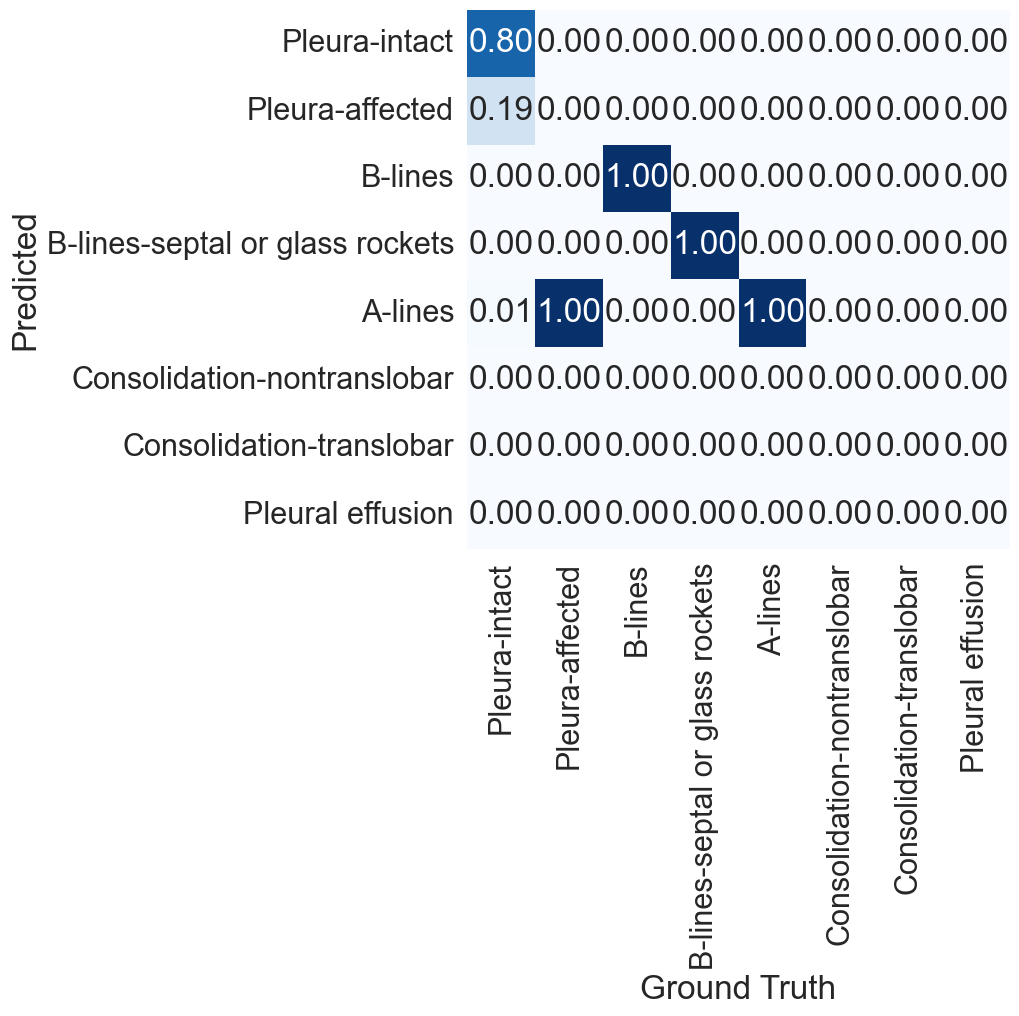

In [27]:
def plot_confusion_matrix_from_results(results, class_labels=None, normalize=True,
                                      figsize=(7, 7), save_path=None):
    """Plot (and optionally save) the confusion matrix from a YOLO validation result.

    By default, this shows **ground truth on the x-axis** and **predicted on the y-axis**,
    matching the orientation you requested.

    Parameters
    ----------
    results : object
        The object returned by model.val(...), expected to have
        results.confusion_matrix.matrix.
    class_labels : list of str, optional
        Human-readable class labels. If None, uses class_names_from_yaml.
    normalize : bool, optional
        If True, normalize each row of the underlying matrix (over ground-truth).
    figsize : tuple, optional
        Matplotlib figure size.
    save_path : str or Path, optional
        If provided, save the figure to this path.
    """
    # Get raw confusion matrix from YOLO
    cm_attr = getattr(results, "confusion_matrix", None)
    if cm_attr is None or getattr(cm_attr, "matrix", None) is None:
        raise ValueError(
            "results.confusion_matrix.matrix not found; run validation with plots=True first."
        )

    cm = np.asarray(cm_attr.matrix)

    # YOLO confusion matrix usually has background as last row/col; drop it
    if cm.ndim == 2 and cm.shape[0] == cm.shape[1] and cm.shape[0] > 1:
        cm = cm[:-1, :-1]

    num_classes = cm.shape[0]

    # Resolve class labels
    if class_labels is None:
        class_labels = [class_names_from_yaml.get(i, str(i)) for i in range(num_classes)]
    else:
        class_labels = list(class_labels)

    # Optional normalization by row (ground truth)
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # avoid division by zero
        cm = cm / row_sums
        fmt = ".2f"
    else:
        fmt = "g"

    # We want ground truth on x-axis, predicted on y-axis -> transpose for plotting
    cm_to_plot = cm.T

    # Build DataFrame for seaborn
    df_cm = pd.DataFrame(
        cm_to_plot,
        index=[str(c) for c in class_labels],      # y-axis (Predicted)
        columns=[str(c) for c in class_labels],    # x-axis (Ground Truth)
    )

    # Plot with seaborn
    plt.figure(figsize=figsize)
    sn.set_theme(font_scale=2)
    sn.heatmap(df_cm, annot=True, cmap="Blues", cbar=False, fmt=fmt)
    plt.xlabel("Ground Truth")
    plt.ylabel("Predicted")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    return df_cm

# Example usage after running validation:
df_cm = plot_confusion_matrix_from_results(results, save_path='confusion_matrix_val.png')

In [21]:
# Extract and display key metrics: mAP, precision, recall

# YOLOv8 returns metrics in results.box for detection tasks
metrics = results.box

# Common metrics (see ultralytics docs for full list)
map50 = metrics.map50          # mAP@0.5
map5095 = metrics.map          # mAP@0.5:0.95
precision = metrics.mp         # mean precision over classes
recall = metrics.mr            # mean recall over classes

print('mAP@0.5:      ', map50)
print('mAP@0.5:0.95: ', map5095)
print('Precision:    ', precision)
print('Recall:       ', recall)


mAP@0.5:       0.10071466435922981
mAP@0.5:0.95:  0.04351134933785348
Precision:     0.3472471297660447
Recall:        0.09574074133515842


In [22]:
# Confusion matrix (numeric values and plot)

cm = results.confusion_matrix  # ultralytics.yolo.utils.metrics.ConfusionMatrix
matrix = cm.matrix             # raw confusion matrix as a 2D array (num_classes x num_classes)

# Prefer class names from dataset YAML, fall back to results.names if needed
try:
    class_names = class_names_from_yaml
except NameError:
    class_names = results.names

print('Confusion matrix (rows=true, cols=pred):')
print(matrix)
print('Class names (index -> name):', class_names)

# Plot confusion matrix using YOLO's built-in helper
fig = cm.plot(names=class_names)
plt.show()

Confusion matrix (rows=true, cols=pred):
[[         75          18           0           0           1           0           0           0          29]
 [          0           0           0           0           6           0           0           0           7]
 [          0           0           1           0           0           0           0           0           4]
 [          0           0           0          18           0           0           0           0           3]
 [          0           0           0           0           7           0           0           0           3]
 [          0           0           0           0           0           0           0           0           0]
 [          0           0           0           0           0           0           0           0           0]
 [          0           0           0           0           0           0           0           0           0]
 [        238         511          47         117         366         2